# Example - optical pulses
A comparison between the Split Step Fourier and Finite-Difference method in analysing the soliton collision of a type of Nonlinear Schrödinger equation found in the context of optical pulses
- https://arxiv.org/pdf/1709.04805.pdf

In [41]:
#=-----------------------------------------------------------------------=#

In [27]:
%%writefile helper.py
import numpy as np
from sympy import *
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

def initOneSoliton(off, v, L, N, S):
    psi = np.zeros(N, dtype=np.complex_)
    t = 0
    h = L/N
    a = np.sqrt(2)
    B = 3/2 - 2 * S
    for i in range(N):
        x = i * h - off
        f = (2 * a * exp(a * x)) / (1 + B * exp(2 * a * x))
        psi[i] = f * exp(I * t + I * v * x)
    return psi

def initTwoSoliton(x1off, v1, x2off, v2, L, N, S):
    psi = np.zeros(N, dtype=np.complex_)
    t = 0
    h = L/N
    a = np.sqrt(2)
    B = 3/2 - 2 * S
    for i in range(N):
        x1 = i * h - x1off
        f1 = ( 2 * a * exp(a * x1)) / (1 + B * exp(2 * a * x1) )
        x2 = i * h - x2off
        f2 = ( 2 * a * exp(a * x2)) / (1 + B * exp(2 * a * x2) )
        psi[i] = ( f1 * exp(I * t + I * v1 * x1) + f2 * 
                    exp(I * t + I * v2 * x2) )
    return psi

def computeN(psi1, psi2, L, N):
    N1 = np.trapz(abs(psi1), dx=L/N)
    N2 = np.trapz(abs(psi2), dx=L/N)
    return np.abs(N1 - N2)

def plot2D(y, L, N):
    plt.plot(np.linspace(0, L, num=N), abs(y))
    plt.show()

def plot3D(psiEv, L, N, T, tau):
    fig = plt.figure(figsize=(20,10))
    ax = fig.gca(projection='3d')

    # Make data.
    X = np.arange(0, L, L/N)
    Y = np.arange(0, T, tau)
    X, Y = np.meshgrid(X, Y)

    # Plot the surface.
    surf = ax.plot_surface(X, Y, psiEv, cmap=cm.jet, linewidth=10,
       antialiased=True, rstride=1, cstride=1)

    # Customize the z axis.
    ax.set_zlim(0, 2)
    ax.zaxis.set_major_locator(LinearLocator(10))
    #ax.zaxis.set_major_formatter(FormatStrFormatter('%.1f
    #ax.view_init(30, 190)

    # Add a color bar which maps values to colors.
    fig.colorbar(surf, shrink=0.5, aspect=10)

    plt.show()

Overwriting helper.py


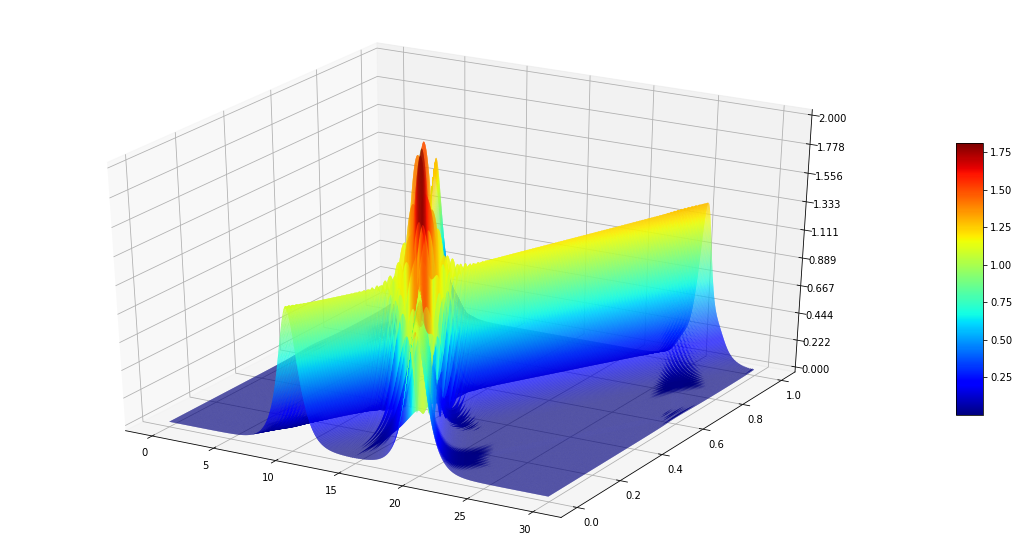

In [24]:
# FiniteDifference.py
import numpy as np
from sympy import *
import helper as h

def FD(phi1):
    newPhi = np.zeros(N, dtype=np.complex_)
    h = L/N
    for i in range(0, N):
        if(i == 0):
            phixx = (phi1[N - 1] - 2 * phi1[i] + phi1[i + 1]) / (h * h)
        elif(i == N-1):
            phixx = (phi1[i - 1] - 2 * phi1[i] + phi1[0]) / (h * h)
        else:
            phixx = (phi1[i - 1] - 2 * phi1[i] + phi1[i + 1]) / (h * h)
        psiSquared = np.abs(phi1[i]) * np.abs(phi1[i])
        A = psiSquared / (1 + S * psiSquared)
        newPhi[i] = I * tau * ((1/2) * phixx + A * phi1[i]) + phi1[i]
    return newPhi

def CD(phi1, phi2):
    newPhi = np.zeros(N, dtype=np.complex_)
    h = L/N
    for i in range(0, N):
        if(i == 0):
             phixx = (phi1[N - 1] - 2 * phi1[i] + phi1[i + 1]) / (h * h)
        elif(i == N-1):
             phixx = (phi1[i - 1] - 2 * phi1[i] + phi1[0]) / (h * h)
        else:
             phixx = (phi1[i - 1] - 2 * phi1[i] + phi1[i + 1]) / (h * h)
        psiSquared = np.abs(phi1[i]) * np.abs(phi1[i])
        A = psiSquared / (1 + S * psiSquared)
        newPhi[i] = 2 * I * tau * ((1/2) * phixx + A * phi1[i]) + phi2[i]
    return newPhi

T   =  1
tau =  .001    # 0.001
L   =  30
N   =  512
S   = -0.1     # 3/4 -0.1

# Run the Simulation
# initTwoSoliton(x1off, v1, x2off, v2, L, N, S)
firstPsi = h.initTwoSoliton(10, 20, 20, -20, L, N, S)
secondPsi = FD(firstPsi)
psiEv = np.zeros(shape=(int(T/tau), int(N)))
for i in range(int(T/tau)):
    psiEv[i] = abs(firstPsi)
    # h.plot2D(firstPsi, L, N) # Plot 2D graph at every time step
    temp = firstPsi
    firstPsi = secondPsi
    secondPsi = CD(secondPsi, temp)
h.plot3D(psiEv, L, N, T, tau) # Plot 3D graph

def computeN():
    firstPsi = h.initOneSoliton(8, 20, L, N, S)
    secondPsi = FD(firstPsi)
    psi1 = firstPsi
    for i in range(8):
        temp = firstPsi
        firstPsi = secondPsi
        secondPsi = CD(secondPsi, temp)
    print(h.computeN(psi1, secondPsi, L, N))

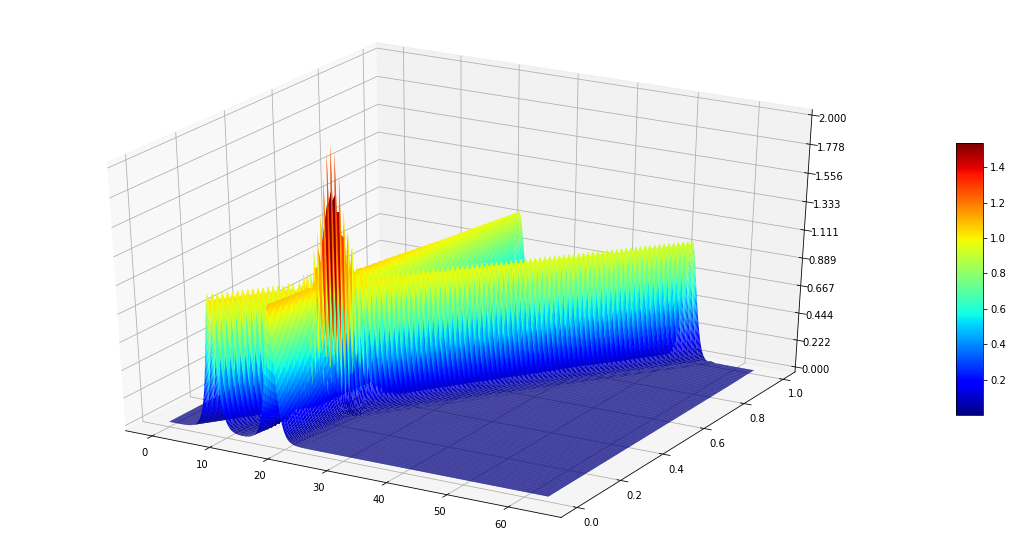

In [26]:
# SplitStep.py
import numpy as np
from sympy import *
from importlib import reload  
import helper as h
reload(h)

def splitstep(psi):
    # Nonlinear Part
    for i in range(N):
        c = (abs(psi[i]) * abs(psi[i]))
        coef = (I * c) / (1 + S * c)
        psi[i] = psi[i] * exp(coef * tau)
    #=======================================
    # Fourier Transform
    c = np.fft.fftshift(np.fft.fft(psi))
    # Move in Fourier Space
    # n = np.linspace(-N/2, N/2+1, num=N)
    for i in range(N):
        e = (-2 * i * i * pi * pi) / (L * L);
        c[i] = exp(tau * I * e) * c[i];
    #=======================================
    # Convert back to physical space
    psi = np.fft.ifft(np.fft.fftshift(c));
    return psi

T   =  1
tau =  .01    # 0.01
L   =  64
N   =  512
S   = -.1    #3/4 - 0.1

# Run the Simulation
# initTwoSoliton(x1off, v1, x2off, v2, L, N, S)
psi = h.initTwoSoliton(8, 20, 18, -20, L, N, S)
psiEv = np.zeros(shape=(int(T/tau), int(N)))
for i in range(int(T/tau)):
    psiEv[i] = abs(psi)
    # h.plot2D(psi, L, N) # Plot 2D graph at every time step
    psi = splitstep(psi)
h.plot3D(psiEv, L, N, T, tau) # Plot 3D graph

def computeN():
    psi1 = h.initOneSoliton(8, 10, L, N, S)
    psi2 = psi1
    for i in range(8):
        h.plot2D(psi2, L, N)
        psi2 = splitstep(psi2)
    print(h.computeN(psi1, psi2, L, N))


- A soliton or solitary wave is a self-reinforcing wave packet that maintains its shape while it propagates at a constant velocity.
- The code is used to study the collision of two such solitons.
- The Split Step method is a pseudo-spectral numerical method used to solve nonlinear PDEs.
- The method works by splitting the equation into a nonlinear and linear part.
- Both these equations are treated separately. The soliton is advanced in time by taking a small time step τ for both solutions.
- For the linear solution however ψ needs to be Fourier transformed with the solution being advanced in Fourier space before inverse Fourier transforming back to the time domain.

\begin{equation}
i\dfrac{\partial \psi}{\partial t} + \dfrac{|\psi|^2\psi}{1+S|\psi|^2} = 0
\end{equation}

\begin{equation}
i\dfrac{\partial \psi}{\partial t} + \dfrac{1}{2} \dfrac{\partial^2 \psi}{\partial x^2} = 0
\end{equation}

## Shows data used in FFT

In [32]:
# SplitStep.py
# draft - experiments and tests

import numpy as np
from sympy import *
from importlib import reload  
import helper as h
reload(h)

def splitstep(psi):
    # Nonlinear Part
    for i in range(N):
        c = (abs(psi[i]) * abs(psi[i]))
        coef = (I * c) / (1 + S * c)
        psi[i] = psi[i] * exp(coef * tau)
    #=======================================
    # Fourier Transform
    # fftshift = Shift the zero-frequency component to the center of
    #            the spectrum. 
    c = np.fft.fftshift(np.fft.fft(psi))
    print(c)
    # Move in Fourier Space
    # n = np.linspace(-N/2, N/2+1, num=N)
    for i in range(N):
        e = (-2 * i * i * pi * pi) / (L * L);
        c[i] = exp(tau * I * e) * c[i];
    #=======================================
    # Convert back to physical space
    psi = np.fft.ifft(np.fft.fftshift(c));
    print()
    print(psi)
    return psi

T   =  1
tau =  1    # 0.01
L   =  64
N   =  8
S   = -.1    #3/4 - 0.1

# Run the Simulation
# initTwoSoliton(x1off, v1, x2off, v2, L, N, S)
psi = h.initTwoSoliton(8, 20, 18, -20, L, N, S)
psiEv = np.zeros(shape=(int(T/tau), int(N)))
for i in range(int(T/tau)):
    psiEv[i] = abs(psi)
    psi = splitstep(psi)
#h.plot3D(psiEv, L, N, T, tau) # Plot 3D graph

[-0.46206081-0.86734172j -0.82349798-0.33878271j -0.87423794+0.22649868j
 -0.57388375+0.83060556j  0.23350317+1.10875922j  1.06486327+0.56725783j
  1.10266086-0.46794647j  0.33238376-1.059111j  ]

[-0.02124634-0.04252994j  0.43297387+0.9467767j  -0.07907388+0.17378016j
 -0.02714867-0.00496588j  0.01919078-0.00442483j -0.01426161+0.01068849j
  0.00920754-0.01675719j -0.00142469+0.02491061j]
